In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SB03.txt")    

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 50  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 8
Number of requests per episode (T_d): 50
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10, 10, 10, 10, 10]
Instance: [[0.414, 1, 1, 2, 1, 0, 0, 0, 0], [0.39, 2, 1, 2, 1, 0, 0, 0, 0], [0.205, 3, 1, 1, 2, 0, 0, 0, 0], [0.614, 1, 2, 1, 1, 0, 0, 0, 0], [0.184, 1, 1, 1, 3, 0, 0, 0, 0], [0.236, 1, 1, 1, 1, 0, 0, 0, 0], [0.255, 3, 3, 1, 1, 0, 0, 0, 0], [0.137, 2, 1, 2, 2, 0, 0, 0, 0], [0.779, 1, 1, 1, 1, 0, 0, 0, 0], [0.089, 2, 1, 1, 1, 0, 0, 0, 0], [0.258, 2, 2, 1, 1, 0, 0, 0, 0], [0.747, 1, 1, 1, 1, 0, 0, 0, 0], [0.393, 1, 1, 1, 2, 0, 0, 0, 0], [0.544, 1, 1, 2, 1, 0, 0, 0, 0], [0.701, 1, 1, 1, 1, 0, 0, 0, 0], [0.718, 1, 1, 1, 1, 0, 0, 0, 0], [0.552, 1, 2, 1, 3, 0, 0, 0, 0], [0.092, 3, 2, 2, 1, 0, 0, 0, 0], [0.961, 1, 1, 1, 1, 0, 0, 0, 0], [0.639, 3, 1, 2, 1, 0, 0, 0, 0], [0.502, 1, 1, 1, 1, 0, 0, 0, 0], [0.205, 2, 1, 2, 2, 0, 0, 0, 0], [0.432, 1, 1, 1, 1, 0, 0, 0, 0], [0.74, 1, 2, 1, 4, 0, 0, 0, 0], [0.628, 1, 1, 2, 1, 0, 0, 0, 0], [0.603, 1, 1, 1, 1, 0, 0, 

In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [0.089, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 2: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 3: [0.542, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 4: [0.628, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 5: [0.393, 1, 1, 1, 2, 0, 0, 0, 0]
  Anfrage 6: [0.184, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 7: [0.398, 1, 2, 4, 1, 0, 0, 0, 0]
  Anfrage 8: [0.258, 2, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 9: [0.089, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 10: [0.383, 3, 5, 1, 1, 0, 0, 0, 0]
  Anfrage 11: [0.552, 1, 2, 1, 3, 0, 0, 0, 0]
  Anfrage 12: [0.502, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 13: [0.699, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 14: [0.603, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 15: [0.694, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 16: [0.628, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 17: [0.701, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 18: [0.347, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 19: [0.432, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 20: [0.383, 3, 5, 1, 1, 0, 0, 0, 0]
  Anfrage 21: [0.236, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 22: [0.236, 1, 

(array([ 1.   , 10.   , 10.   , 10.   , 10.   , 10.   , 10.   , 10.   ,
        10.   ,  0.089,  2.   ,  1.   ,  1.   ,  1.   ,  0.   ,  0.   ,
         0.   ,  0.   ], dtype=float32),
 {'valid_actions': [0, 1, 2, 3, 4, 5]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1.    10.    10.    10.    10.    10.    10.    10.    10.     0.871
  2.     1.     1.     1.     0.     0.     0.     0.   ]
t=2    Caps=[8, 9, 9, 9, 10, 10, 10, 10]  r=0.70  q=[3, 1, 2, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=3    Caps=[5, 8, 7, 8, 10, 10, 10, 10]  r=0.24  q=[1, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=4    Caps=[4, 7, 6, 7, 10, 10, 10, 10]  r=0.73  q=[2, 2, 1, 2, 0, 0, 0, 0]  Valid Actions: [0, 1, 2, 3, 4, 5]
t=5    Caps=[2, 5, 5, 5, 10, 10, 10, 10]  r=0.38  q=[3, 5, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 2, 3, 4, 5]
t=6    Caps=[-1, 0, 4, 4, 10, 10, 10, 10]  r=0.78  q=[1, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 3, 4, 5]
True
t=6    Caps=[-2, -1, 3, 3, 10, 10, 10, 10]  r=0.78  q=[1, 1, 1, 1, 0, 0, 0, 0]  Valid Actions: [0, 3, 4, 5]


In [5]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.99, epsilon_decay_steps=50000)

In [6]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=10000)

  Systematic monotonicity (Episode 1): C_k: 39.6%, t: 40.2%, r: 50.3%, q: 73.6%, mixed: 46.6%
Episode   50/10000  Reward:     4.31  Avg(50):     4.79  Tiefe:   42  Avg-Tiefe(50):   35.8  ε: 0.968
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 47.6%, r: 97.0%, q: 65.8%, mixed: 99.4%
Episode  100/10000  Reward:     4.80  Avg(50):     4.76  Tiefe:   32  Avg-Tiefe(50):   32.8  ε: 0.940
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 33.1%, r: 100.0%, q: 87.6%, mixed: 100.0%
Episode  150/10000  Reward:     5.06  Avg(50):     4.89  Tiefe:   47  Avg-Tiefe(50):   33.2  ε: 0.913
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 19.9%, r: 100.0%, q: 85.2%, mixed: 100.0%
Episode  200/10000  Reward:     5.23  Avg(50):     5.20  Tiefe:   50  Avg-Tiefe(50):   33.7  ε: 0.886
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 16.9%, r: 100.0%, q: 84.6%, mixed: 100.0%
Episode  250/10000  Reward:     6.54  Avg(50):     5.40  Tiefe:   43  Avg-Tiefe(50):   33.3  ε: 0.860
  S

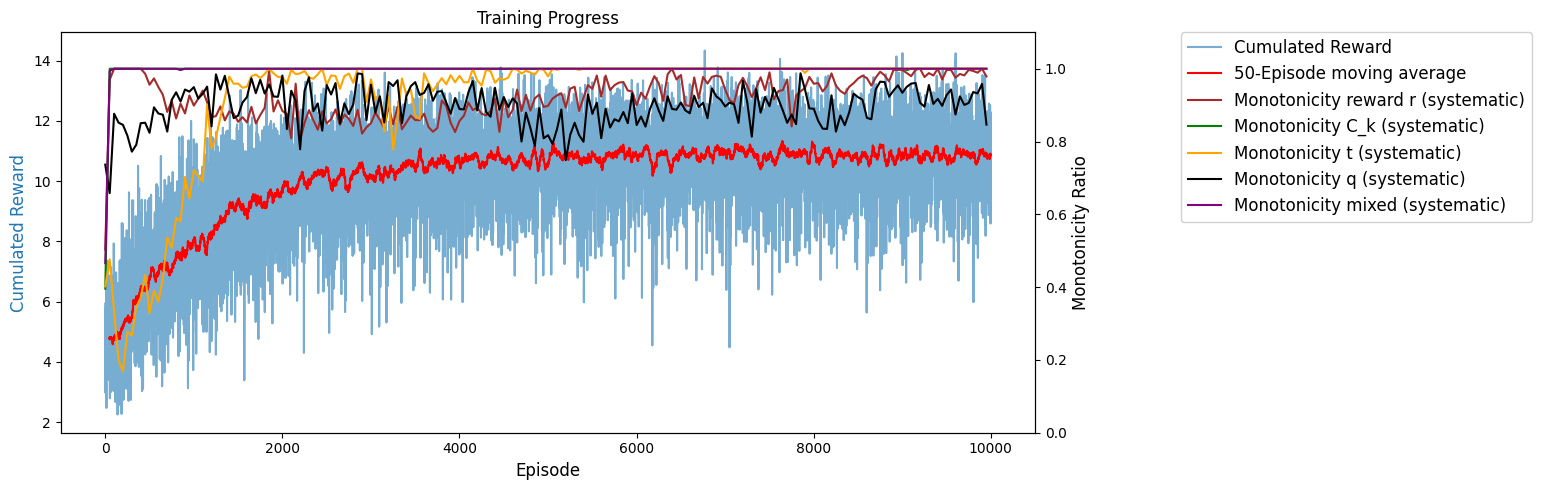

In [7]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

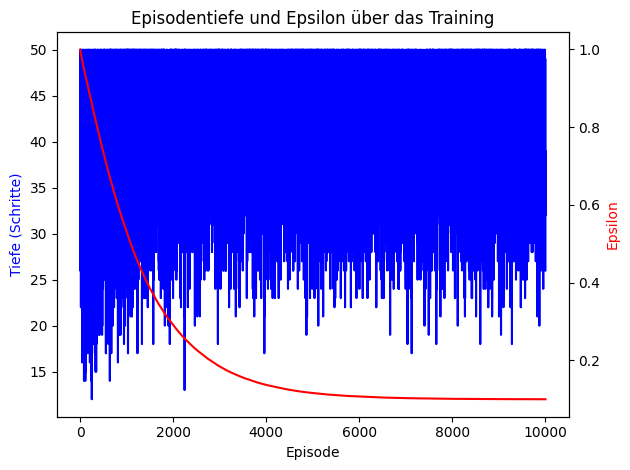

In [8]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [9]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [0.871, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 2: [0.718, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 3: [0.779, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 4: [0.581, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 5: [0.808, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 6: [0.347, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 7: [0.09, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 8: [0.473, 1, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 9: [0.699, 3, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 10: [0.734, 2, 2, 1, 2, 0, 0, 0, 0]
  Anfrage 11: [0.218, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 12: [0.677, 1, 2, 1, 1, 0, 0, 0, 0]
  Anfrage 13: [0.184, 1, 1, 1, 3, 0, 0, 0, 0]
  Anfrage 14: [0.812, 2, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 15: [0.205, 3, 1, 1, 2, 0, 0, 0, 0]
  Anfrage 16: [0.218, 1, 1, 1, 1, 0, 0, 0, 0]
  Anfrage 17: [0.843, 1, 3, 1, 1, 0, 0, 0, 0]
  Anfrage 18: [0.473, 1, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 19: [0.414, 1, 1, 2, 1, 0, 0, 0, 0]
  Anfrage 20: [0.092, 3, 2, 2, 1, 0, 0, 0, 0]
  Anfrage 21: [0.137, 2, 1, 2, 2, 0, 0, 0, 0]
  Anfrage 22: [0.542, 1, 2

## Analyse der Reward-History

Diese Zelle berechnet einfache Kennzahlen (Mean, Std, Median, AUC, Final-Mean) aus der vorhandenen `reward_history`-Liste und zeigt einen Plot mit gleitendem Durchschnitt.

Episoden: 10000
Mean: 10.1015, Std: 1.8877, Median: 10.4915
Max: 14.3370, Min: 2.2510


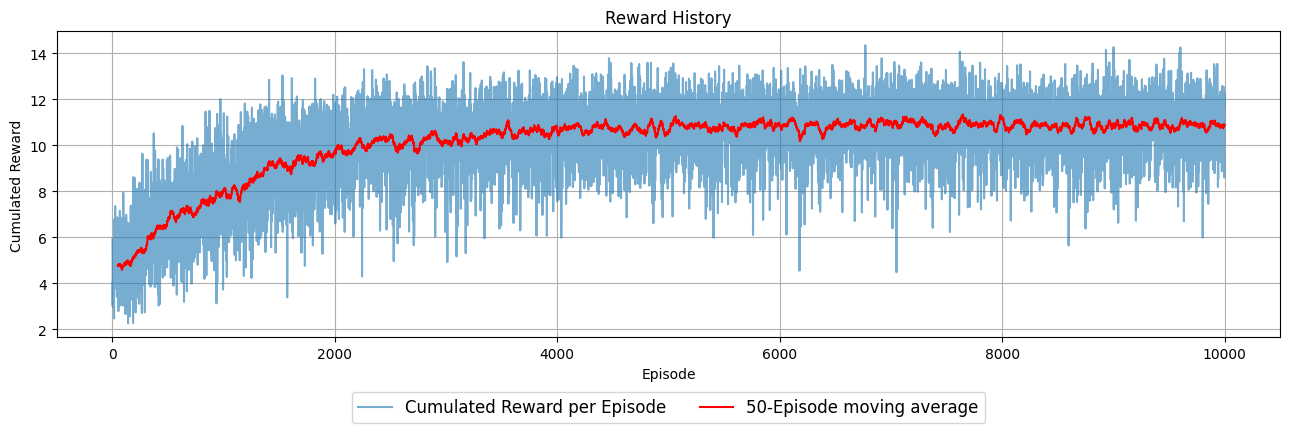

{'n': 10000,
 'mean': 10.101475939920544,
 'std': 1.8877477175193218,
 'median': 10.491500034928322,
 'max': 14.336999952793121,
 'min': 2.2509999722242355}

In [10]:
from training.plotting import plot_reward_moving_average
plot_reward_moving_average(reward_history, window=50)

## Evaluationsphase (eingefrorene Parameter, epsilon=0)

Nach abgeschlossenem Training werden die Netzgewichte fixiert (keine weiteren Trainingsschritte, `epsilon=0`, reines Exploitation) und für 10.000 Episoden evaluiert, um eine stabile Schätzung der Performance zu erhalten.

In [13]:
eval_rewards, eval_depths = agent.evaluate(num_episodes=10000)

[Eval] Episode   500/10000  Reward:    11.47  Avg(500):    11.59  Avg-Tiefe(500):   42.7
[Eval] Episode  1000/10000  Reward:    12.56  Avg(500):    11.65  Avg-Tiefe(500):   42.9
[Eval] Episode  1500/10000  Reward:    11.36  Avg(500):    11.60  Avg-Tiefe(500):   43.2
[Eval] Episode  2000/10000  Reward:    12.05  Avg(500):    11.64  Avg-Tiefe(500):   43.6
[Eval] Episode  2500/10000  Reward:    13.35  Avg(500):    11.55  Avg-Tiefe(500):   43.5
[Eval] Episode  3000/10000  Reward:     9.02  Avg(500):    11.62  Avg-Tiefe(500):   43.3
[Eval] Episode  3500/10000  Reward:    11.66  Avg(500):    11.63  Avg-Tiefe(500):   43.2
[Eval] Episode  4000/10000  Reward:    10.81  Avg(500):    11.51  Avg-Tiefe(500):   43.1
[Eval] Episode  4500/10000  Reward:    11.12  Avg(500):    11.58  Avg-Tiefe(500):   42.8
[Eval] Episode  5000/10000  Reward:    10.00  Avg(500):    11.68  Avg-Tiefe(500):   43.4
[Eval] Episode  5500/10000  Reward:    11.36  Avg(500):    11.61  Avg-Tiefe(500):   42.4
[Eval] Episode  6000/

Eval-Episoden: 10000
Mean: 11.6255, Std: 0.9531, Median: 11.6740
Max: 15.0500, Min: 5.5110


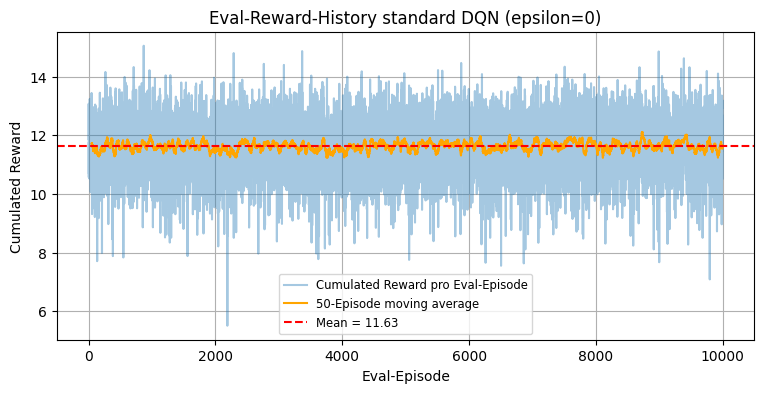

In [14]:
from training.plotting import plot_eval_rewards

eval_stats = plot_eval_rewards(eval_rewards, title="Eval-Reward-History standard DQN (epsilon=0)")